In [13]:
import pandas as pd
import numpy as np

In [19]:
import os

base_path = r"C:/Users/deep8/Downloads/Project data/New_Pipeline"

# list all folders
folders = [f for f in os.listdir(base_path) 
           if os.path.isdir(os.path.join(base_path, f))]

folders


['0019c951-16c5-48d0-85c8-58d96b12d330',
 '0022cd20-f64f-4773-b9ff-a3de0b71b259',
 '00469928-b243-4cae-acd7-134508e99ceb',
 '0081f507-b104-4214-9ea1-31dd69130991',
 '0094f9d0-45ec-4aad-bca0-71c60bdd7113',
 '00b13ccf-ad7c-4613-8366-7c583a399691',
 '010e405c-b91d-4046-898e-105d5830d9a9',
 '017d71aa-0999-4d8e-9cb4-88b9013e61eb',
 '02a0b95f-ea0f-4c0d-ba2d-9724ed9ad712',
 '02a11397-2a9b-4dba-8c6a-6b9f0aa24372',
 '02e08315-4d34-421c-acc0-129b1e1de38b',
 '03891509-3109-450d-8564-77b024a6128e',
 '03a1a105-4856-4e5c-b537-508bdbda50b5',
 '03d18286-1038-4c0c-9c05-d1269e280250',
 '04024f75-7405-4ccc-8976-91d0a3035b3a',
 '040d00da-2bc9-49d4-bf6c-b4515b6a2bbf',
 '0427af63-b665-4c57-874b-65222c200bfe',
 '0437af11-bb89-4901-9764-bb410c2e94c5',
 '046fe29e-7c99-4093-8565-f2f205a00796',
 '04a7cce8-c3b3-4994-9dac-c0e53099f37d',
 '04e03ae1-b2f3-446d-862d-172fea6320de',
 '051a1102-a815-4b39-b903-80d8b4a2348f',
 '0525bcb6-d206-46c8-b37d-b9b7cc90fef6',
 '055f6138-ea7a-468d-90c2-87a473486867',
 '05aa6d12-6d48-

In [21]:
# pick the first UUID folder and list its contents
sample_folder = folders[0]

os.listdir(os.path.join(base_path, sample_folder))


['ba295155-272e-43eb-9d6a-e4c9c392e68b.rna_seq.augmented_star_gene_counts.tsv',
 'logs']

In [23]:
# full path to one RNA-seq file
rna_file = os.path.join(
    base_path,
    sample_folder,
    "ba295155-272e-43eb-9d6a-e4c9c392e68b.rna_seq.augmented_star_gene_counts.tsv"
)

# read file
df_single = pd.read_csv(rna_file, sep="\t")

# preview
df_single.head()


,,,,,,,,# gene-model: GENCODE v36
gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
N_unmapped,NaN,NaN,1884156,1884156,1884156,NaN,NaN,NaN
N_multimapping,NaN,NaN,5772894,5772894,5772894,NaN,NaN,NaN
N_noFeature,NaN,NaN,3331800,41101584,41057602,NaN,NaN,NaN
N_ambiguous,NaN,NaN,6974507,1651293,1654961,NaN,NaN,NaN


In [29]:
# convert index into a column
df_single = df_single.reset_index()

# check columns
df_single.columns


Index(['level_0', 'level_1', 'level_2', 'level_3', 'level_4', 'level_5',
       'level_6', 'level_7', '# gene-model: GENCODE v36'],
      dtype='object')

In [31]:
# reload file with correct header handling
df_single = pd.read_csv(
    rna_file,
    sep="\t",
    comment="#",      # ignore STAR metadata line
    header=0
)

# check columns now
df_single.columns


Index(['gene_id', 'gene_name', 'gene_type', 'unstranded', 'stranded_first',
       'stranded_second', 'tpm_unstranded', 'fpkm_unstranded',
       'fpkm_uq_unstranded'],
      dtype='object')

In [33]:
# remove STAR summary rows
df_genes = df_single[~df_single["gene_id"].str.startswith("N_")]

# keep only protein-coding genes
df_genes = df_genes[df_genes["gene_type"] == "protein_coding"]

# check
df_genes.shape


(19962, 9)

In [35]:
# extract TPM only
expr_tpm = df_genes[["gene_id", "tpm_unstranded"]].copy()

# set gene_id as index
expr_tpm = expr_tpm.set_index("gene_id")

# rename column with sample UUID
expr_tpm.columns = [sample_folder]

# check
expr_tpm.head()


,0019c951-16c5-48d0-85c8-58d96b12d330
gene_id,
ENSG00000000003.15,56.2216
ENSG00000000005.6,0.2768
ENSG00000000419.13,126.9161
ENSG00000000457.14,25.4778
ENSG00000000460.17,15.4251


In [41]:
from glob import glob

expr_list = []

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    
    # find STAR gene-count file inside folder
    files = glob(os.path.join(folder_path, "*.rna_seq.augmented_star_gene_counts.tsv"))
    
    if len(files) == 0:
        continue
    
    file_path = files[0]  # only one file per folder
    
    df = pd.read_csv(file_path, sep="\t", comment="#")
    
    # clean
    df = df[~df["gene_id"].str.startswith("N_")]
    df = df[df["gene_type"] == "protein_coding"]
    
    # extract TPM
    tmp = df[["gene_id", "tpm_unstranded"]].set_index("gene_id")
    tmp.columns = [folder]   # use folder UUID as sample ID
    
    expr_list.append(tmp)

# merge all samples
expr_matrix = pd.concat(expr_list, axis=1)

# final check
expr_matrix.shape


KeyboardInterrupt: 

In [43]:
from glob import glob

expr_list = []

# LIMIT to first 20 folders for testing
test_folders = folders[:20]

for folder in test_folders:
    folder_path = os.path.join(base_path, folder)
    files = glob(os.path.join(folder_path, "*.rna_seq.augmented_star_gene_counts.tsv"))
    
    if not files:
        continue
    
    df = pd.read_csv(files[0], sep="\t", comment="#")
    df = df[~df["gene_id"].str.startswith("N_")]
    df = df[df["gene_type"] == "protein_coding"]
    
    tmp = df[["gene_id", "tpm_unstranded"]].set_index("gene_id")
    tmp.columns = [folder]
    
    expr_list.append(tmp)

expr_matrix_test = pd.concat(expr_list, axis=1)
expr_matrix_test.shape


(19962, 20)

In [45]:
from glob import glob

expr_matrix = None

for i, folder in enumerate(folders):
    folder_path = os.path.join(base_path, folder)
    files = glob(os.path.join(folder_path, "*.rna_seq.augmented_star_gene_counts.tsv"))
    
    if not files:
        continue
    
    df = pd.read_csv(
        files[0],
        sep="\t",
        comment="#",
        usecols=["gene_id", "gene_type", "tpm_unstranded"]
    )
    
    df = df[(~df["gene_id"].str.startswith("N_")) &
            (df["gene_type"] == "protein_coding")]
    
    tmp = df.set_index("gene_id")[["tpm_unstranded"]]
    tmp.columns = [folder]
    
    # incremental merge (low memory)
    if expr_matrix is None:
        expr_matrix = tmp
    else:
        expr_matrix = expr_matrix.join(tmp, how="inner")
    
    if i % 25 == 0:
        print(f"Processed {i} samples")

expr_matrix.shape


Processed 0 samples
Processed 25 samples
Processed 50 samples
Processed 75 samples
Processed 100 samples
Processed 125 samples
Processed 150 samples
Processed 175 samples
Processed 200 samples
Processed 225 samples
Processed 250 samples
Processed 275 samples
Processed 300 samples
Processed 325 samples
Processed 350 samples
Processed 375 samples
Processed 400 samples
Processed 425 samples
Processed 450 samples
Processed 475 samples
Processed 500 samples
Processed 525 samples
Processed 550 samples
Processed 575 samples
Processed 600 samples
Processed 625 samples
Processed 650 samples
Processed 675 samples
Processed 700 samples
Processed 725 samples
Processed 750 samples
Processed 775 samples
Processed 800 samples
Processed 825 samples
Processed 850 samples
Processed 875 samples
Processed 900 samples
Processed 925 samples
Processed 950 samples
Processed 975 samples
Processed 1000 samples
Processed 1025 samples
Processed 1050 samples
Processed 1075 samples
Processed 1100 samples
Processed 

(19962, 1231)

In [51]:
import os

# create directory first
os.makedirs("breast_cancer_project", exist_ok=True)

# now save the file
expr_matrix.to_csv(
    "breast_cancer_project/TCGA_BRCA_expression_TPM.csv.gz",
    compression="gzip"
)


In [53]:
import pandas as pd
import numpy as np


In [57]:
import os

# list files to identify clinical & PAM50 data
os.listdir("breast_cancer_project")


['.ipynb_checkpoints', 'TCGA_BRCA_expression_TPM.csv.gz']

In [61]:
import os

os.getcwd()


'C:\\Users\\deep8\\Downloads'

In [65]:
import os

clinical_base = r"C:\Users\deep8\breast_cancer_project_folder"

os.listdir(clinical_base)


['.ipynb_checkpoints',
 'clinical.tsv',
 'exposure.tsv',
 'family_history.tsv',
 'follow_up.tsv',
 'pathology_detail.tsv',
 'TCGA.BRCA (2).sampleMap_BRCA_clinicalMatrix',
 'Untitled.ipynb']

In [67]:
# load main clinical file
clinical = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\clinical.tsv",
    sep="\t"
)

# quick check
clinical.shape, clinical.head()


C:\Users\deep8\AppData\Local\Temp\ipykernel_19676\3148328023.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical = pd.read_csv(


((5546, 210),
   project.project_id                         cases.case_id cases.consent_type  \
 0          TCGA-BRCA  001cef41-ff86-4d3f-a140-a647ac4b10a1   Informed Consent   
 1          TCGA-BRCA  001cef41-ff86-4d3f-a140-a647ac4b10a1   Informed Consent   
 2          TCGA-BRCA  001cef41-ff86-4d3f-a140-a647ac4b10a1   Informed Consent   
 3          TCGA-BRCA  0045349c-69d9-4306-a403-c9c1fa836644   Informed Consent   
 4          TCGA-BRCA  00807dae-9f4a-4fd1-aac2-82eb11bf2afb   Informed Consent   
 
   cases.days_to_consent cases.days_to_lost_to_followup  \
 0                   -34                            '--   
 1                   -34                            '--   
 2                   -34                            '--   
 3                    76                            '--   
 4                    19                            '--   
 
                      cases.disease_type cases.index_date  \
 0          Ductal and Lobular Neoplasms        Diagnosis   
 1          Du

In [69]:

pam50 = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\TCGA.BRCA (2).sampleMap_BRCA_clinicalMatrix",
    sep="\t"
)

pam50.shape, pam50.head()

((1247, 194),
           sampleID AJCC_Stage_nature2012  \
 0  TCGA-3C-AAAU-01                   NaN   
 1  TCGA-3C-AALI-01                   NaN   
 2  TCGA-3C-AALJ-01                   NaN   
 3  TCGA-3C-AALK-01                   NaN   
 4  TCGA-4H-AAAK-01                   NaN   
 
    Age_at_Initial_Pathologic_Diagnosis_nature2012  CN_Clusters_nature2012  \
 0                                             NaN                     NaN   
 1                                             NaN                     NaN   
 2                                             NaN                     NaN   
 3                                             NaN                     NaN   
 4                                             NaN                     NaN   
 
   Converted_Stage_nature2012  Days_to_Date_of_Last_Contact_nature2012  \
 0                        NaN                                      NaN   
 1                        NaN                                      NaN   
 2                    

# extract PAM50 subtypes and align with expression data

In [72]:
# find PAM50-related columns
[p for p in pam50.columns if "PAM50" in p or "pam50" in p.lower()]


['Integrated_Clusters_with_PAM50__nature2012',
 'PAM50Call_RNAseq',
 'PAM50_mRNA_nature2012']

In [74]:
# choose RNA-seq–derived PAM50 (best match to expression data)
pam50_sub = pam50[["sampleID", "PAM50Call_RNAseq"]].dropna()

# standardize sample IDs to match expression columns (first 16 chars)
pam50_sub["sample_short"] = pam50_sub["sampleID"].str[:16]

# load expression (if not already in memory)
expr = pd.read_csv(
    "breast_cancer_project/TCGA_BRCA_expression_TPM.csv.gz",
    index_col=0
)

# intersect samples
common_samples = expr.columns.intersection(pam50_sub["sample_short"])

# subset expression and clinical labels
expr_aligned = expr[common_samples]
pam50_aligned = pam50_sub.set_index("sample_short").loc[common_samples]

# check
expr_aligned.shape, pam50_aligned["PAM50Call_RNAseq"].value_counts()


((19962, 0), Series([], Name: count, dtype: int64))

# Build UUID → PAM50 mapping

In [79]:
# extract UUID used for RNA-seq
uuid_map = pam50[[
    "_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2",
    "PAM50Call_RNAseq"
]].dropna()

# rename for clarity
uuid_map.columns = ["uuid", "PAM50"]

# check
uuid_map.head(), uuid_map.shape


(                                    uuid   PAM50
 8   a2405d64-34eb-4915-abf7-8530151d5cb0  Normal
 9   15bad71d-3031-413b-9e8d-6426ae5dfbea    LumA
 10  a998e0ce-9248-460f-aabc-2dad452a1ff9    LumA
 11  28089e15-5e2c-4e83-ba6c-62b3cb40e431    LumA
 12  0df6b948-367d-4951-9d98-d3bebabff63e    LumA,
 (956, 2))

In [81]:
# load expression matrix (UUID-based columns)
expr = pd.read_csv(
    "breast_cancer_project/TCGA_BRCA_expression_TPM.csv.gz",
    index_col=0
)

# make sure UUID formats match (lowercase)
expr.columns = expr.columns.str.lower()
uuid_map["uuid"] = uuid_map["uuid"].str.lower()

# find common UUIDs
common_uuids = expr.columns.intersection(uuid_map["uuid"])

# subset expression
expr_final = expr[common_uuids]

# subset PAM50 labels
pam50_final = uuid_map.set_index("uuid").loc[common_uuids]

# final check
expr_final.shape, pam50_final["PAM50"].value_counts()


((19962, 0), Series([], Name: count, dtype: int64))

In [83]:
# inspect one column name
expr.columns[0]


'0019c951-16c5-48d0-85c8-58d96b12d330'

In [87]:
import os

base = r"C:\Users\deep8\Downloads"

# search for metadata / manifest files
matches = []
for root, dirs, files in os.walk(base):
    for f in files:
        if "meta" in f.lower() or "manifest" in f.lower() or "files" in f.lower():
            matches.append(os.path.join(root, f))

matches[:10]


['C:\\Users\\deep8\\Downloads\\brca_metabric (1).tar.gz',
 'C:\\Users\\deep8\\Downloads\\brca_metabric (2).tar.gz',
 'C:\\Users\\deep8\\Downloads\\brca_metabric.tar.gz',
 'C:\\Users\\deep8\\Downloads\\brca_metabric_clinical_data.tsv',
 'C:\\Users\\deep8\\Downloads\\files-table.2025-05-14.tsv',
 'C:\\Users\\deep8\\Downloads\\gdc_manifest.2025-06-06.173556.txt',
 'C:\\Users\\deep8\\Downloads\\GSM4285803_scRNA_metaInfo.csv',
 'C:\\Users\\deep8\\Downloads\\HES2 is over-expressed in brain metastatic breast cancer-PDF_112020 (1).pdf',
 'C:\\Users\\deep8\\Downloads\\HES2 is over-expressed in brain metastatic breast cancer-PDF_112020 (2).pdf',
 'C:\\Users\\deep8\\Downloads\\HES2 is over-expressed in brain metastatic breast cancer-PDF_112020.pdf']

In [89]:
import pandas as pd

files_meta = pd.read_csv(
    r"C:\Users\deep8\Downloads\files-table.2025-05-14.tsv",
    sep="\t"
)

files_meta.columns.tolist()


['Access',
 'File Name',
 'Cases',
 'Project',
 'Data Category',
 'Data Format',
 'File Size',
 'Annotations']

In [97]:
import os

os.listdir(r"C:\Users\deep8\breast_cancer_project_folder")


['.ipynb_checkpoints',
 'clinical.tsv',
 'exposure.tsv',
 'family_history.tsv',
 'follow_up.tsv',
 'gdc_manifest.2026-01-23.234051.txt',
 'metadata.cart.2026-01-27.json',
 'metadata.json',
 'pathology_detail.tsv',
 'TCGA.BRCA (2).sampleMap_BRCA_clinicalMatrix',
 'Untitled.ipynb']

In [103]:
import pandas as pd

sample_map = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\TCGA.BRCA (2).sampleMap_BRCA_clinicalMatrix",
    sep="\t"
)

sample_map.shape, sample_map.columns.tolist()


((1247, 194),
 ['sampleID',
  'AJCC_Stage_nature2012',
  'Age_at_Initial_Pathologic_Diagnosis_nature2012',
  'CN_Clusters_nature2012',
  'Converted_Stage_nature2012',
  'Days_to_Date_of_Last_Contact_nature2012',
  'Days_to_date_of_Death_nature2012',
  'ER_Status_nature2012',
  'Gender_nature2012',
  'HER2_Final_Status_nature2012',
  'Integrated_Clusters_no_exp__nature2012',
  'Integrated_Clusters_unsup_exp__nature2012',
  'Integrated_Clusters_with_PAM50__nature2012',
  'Metastasis_Coded_nature2012',
  'Metastasis_nature2012',
  'Node_Coded_nature2012',
  'Node_nature2012',
  'OS_Time_nature2012',
  'OS_event_nature2012',
  'PAM50Call_RNAseq',
  'PAM50_mRNA_nature2012',
  'PR_Status_nature2012',
  'RPPA_Clusters_nature2012',
  'SigClust_Intrinsic_mRNA_nature2012',
  'SigClust_Unsupervised_mRNA_nature2012',
  'Survival_Data_Form_nature2012',
  'Tumor_T1_Coded_nature2012',
  'Tumor_nature2012',
  'Vital_Status_nature2012',
  '_INTEGRATION',
  '_PANCAN_CNA_PANCAN_K8',
  '_PANCAN_Cluster_Cl

In [105]:
# keep sample ID + PAM50 (RNAseq-based)
pam50_df = sample_map[["sampleID", "PAM50Call_RNAseq"]].copy()

# clean column names
pam50_df.columns = ["tcga_sample_id", "PAM50"]

# remove missing PAM50
pam50_df = pam50_df.dropna(subset=["PAM50"])

pam50_df.shape, pam50_df["PAM50"].value_counts()


((956, 2),
 PAM50
 LumA      434
 LumB      194
 Basal     142
 Normal    119
 Her2       67
 Name: count, dtype: int64)

In [107]:
# load expression matrix
expr = pd.read_csv(
    "breast_cancer_project/TCGA_BRCA_expression_TPM.csv.gz",
    index_col=0
)

# expression columns are UUIDs → map them to TCGA sample IDs
# using sampleMap
uuid_to_tcga = sample_map[
    ["_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2", "sampleID"]
].dropna()

uuid_to_tcga.columns = ["uuid", "tcga_sample_id"]

# lowercase for safety
uuid_to_tcga["uuid"] = uuid_to_tcga["uuid"].str.lower()
expr.columns = expr.columns.str.lower()

# keep only UUIDs present in both
common = expr.columns.intersection(uuid_to_tcga["uuid"])

# subset expression
expr_sub = expr[common]

# rename columns from UUID → TCGA sample ID
expr_sub.columns = (
    uuid_to_tcga
    .set_index("uuid")
    .loc[common, "tcga_sample_id"]
)

# now align with PAM50 labels
common_tcga = expr_sub.columns.intersection(pam50_df["tcga_sample_id"])

expr_final = expr_sub[common_tcga]
pam50_final = pam50_df.set_index("tcga_sample_id").loc[common_tcga]

# final check
expr_final.shape, pam50_final["PAM50"].value_counts()


((19962, 0), Series([], Name: count, dtype: int64))

In [111]:
import pandas as pd

# load Xena RNA-seq expression (no unzip needed)
expr = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\TCGA.BRCA.sampleMap_HiSeqV2.gz",
    sep="\t",
    index_col=0
)

# transpose: samples as rows
expr = expr.T

# align with PAM50 labels
common = expr.index.intersection(pam50_df["tcga_sample_id"])

expr_final = expr.loc[common].T
pam50_final = pam50_df.set_index("tcga_sample_id").loc[common]

# final check
expr_final.shape, pam50_final["PAM50"].value_counts()


((20530, 956),
 PAM50
 LumA      434
 LumB      194
 Basal     142
 Normal    119
 Her2       67
 Name: count, dtype: int64)

In [113]:
# save expression + labels for all future steps
expr_final.to_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\TCGA_BRCA_expr_PAM50_aligned.csv.gz",
    compression="gzip"
)

pam50_final.to_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\TCGA_BRCA_PAM50_labels.csv"
)


# Batch correction & filtering

In [116]:
import pandas as pd

# load aligned expression matrix
expr = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\TCGA_BRCA_expr_PAM50_aligned.csv.gz",
    index_col=0
)

# load PAM50 labels
pam50 = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\TCGA_BRCA_PAM50_labels.csv",
    index_col=0
)

# quick checks
expr.shape, pam50["PAM50"].value_counts()


((20530, 956),
 PAM50
 LumA      434
 LumB      194
 Basal     142
 Normal    119
 Her2       67
 Name: count, dtype: int64)

In [118]:
# threshold parameters
min_expr = 1
min_frac = 0.10
min_samples = int(expr.shape[1] * min_frac)

# filter
expr_filt = expr[(expr > min_expr).sum(axis=1) >= min_samples]

# check
expr_filt.shape


(18203, 956)

In [120]:
from sklearn.decomposition import PCA
import pandas as pd

# PCA on filtered expression (samples as rows)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(expr_filt.T)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=expr_filt.columns
)

# attach PAM50 labels
pca_df["PAM50"] = pam50.loc[pca_df.index, "PAM50"]

# variance explained
pca.explained_variance_ratio_


array([0.13765384, 0.10006707])

In [122]:
# quick distribution check
expr_filt.describe().loc[["mean", "std"]]


,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01,TCGA-A8-A096-01,TCGA-BH-A0C7-01,TCGA-AR-A0TV-01,TCGA-BH-A18J-01,TCGA-BH-A0W7-01,TCGA-BH-A0HA-01,...,TCGA-BH-A0HY-01,TCGA-AR-A24T-01,TCGA-E9-A1NF-11,TCGA-AO-A0JA-01,TCGA-D8-A1XZ-01,TCGA-A7-A13E-11,TCGA-AC-A2FB-11,TCGA-B6-A0X7-01,TCGA-BH-A1EV-11,TCGA-B6-A0X1-01
mean,6.979367,7.360735,7.203972,6.982054,7.214638,7.291626,7.042324,7.217845,7.515337,7.328275,...,7.074722,7.294943,7.098397,7.254378,7.137737,7.351424,7.493446,7.317830,7.533471,7.192900
std,3.749730,3.494156,3.586321,3.747416,3.660871,3.531002,3.728963,3.620905,3.390319,3.525001,...,3.704649,3.535897,3.716325,3.563190,3.675389,3.503452,3.403705,3.493225,3.347927,3.560067


# Differential Expression Analysis (DEG)  

In [125]:
# check available subtypes
pam50["PAM50"].value_counts()


PAM50
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64

# Subset samples (Luminal A vs Normal)

In [128]:
# select sample IDs for LumA and Normal
luma_samples = pam50[pam50["PAM50"] == "LumA"].index
normal_samples = pam50[pam50["PAM50"] == "Normal"].index

# subset expression matrix
expr_luma = expr_filt[luma_samples]
expr_normal = expr_filt[normal_samples]

# check shapes
expr_luma.shape, expr_normal.shape


((18203, 434), (18203, 119))

In [130]:
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# compute log2 fold change
log2fc = np.log2(expr_luma.mean(axis=1) + 1e-6) - np.log2(expr_normal.mean(axis=1) + 1e-6)

# statistical test
tstat, pvals = ttest_ind(
    expr_luma.T,
    expr_normal.T,
    axis=0,
    equal_var=False,
    nan_policy="omit"
)

# multiple testing correction
fdr = multipletests(pvals, method="fdr_bh")[1]

# DEG table
deg_luma_vs_normal = pd.DataFrame({
    "log2FC": log2fc,
    "pvalue": pvals,
    "FDR": fdr
}).sort_values("FDR")

# quick check
deg_luma_vs_normal.head()


,log2FC,pvalue,FDR
sample,,,
SFRP1,-0.591238,9.505923e-110,1.730363e-105
LASS2,0.149004,2.417196e-103,2.200011e-99
PRNP,-0.226452,2.289061e-99,1.388926e-95
MID1,-0.431439,4.259273e-99,1.938288e-95
SPRY2,-0.404294,8.588585e-99,3.126760e-95


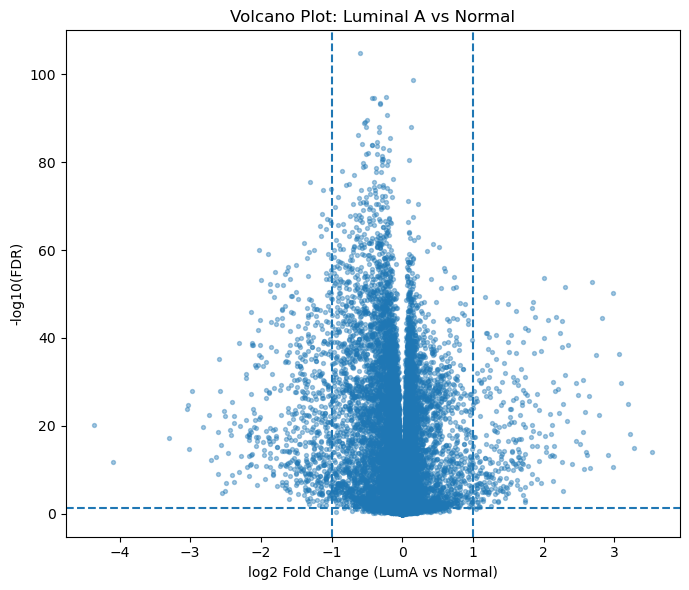

In [132]:
import matplotlib.pyplot as plt
import numpy as np

# prepare data
x = deg_luma_vs_normal["log2FC"]
y = -np.log10(deg_luma_vs_normal["FDR"] + 1e-300)

# thresholds
fc_thr = 1
fdr_thr = 0.05

plt.figure(figsize=(7, 6))
plt.scatter(x, y, s=8, alpha=0.4)

# threshold lines
plt.axvline(fc_thr, linestyle="--")
plt.axvline(-fc_thr, linestyle="--")
plt.axhline(-np.log10(fdr_thr), linestyle="--")

plt.xlabel("log2 Fold Change (LumA vs Normal)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot: Luminal A vs Normal")

plt.tight_layout()
plt.show()


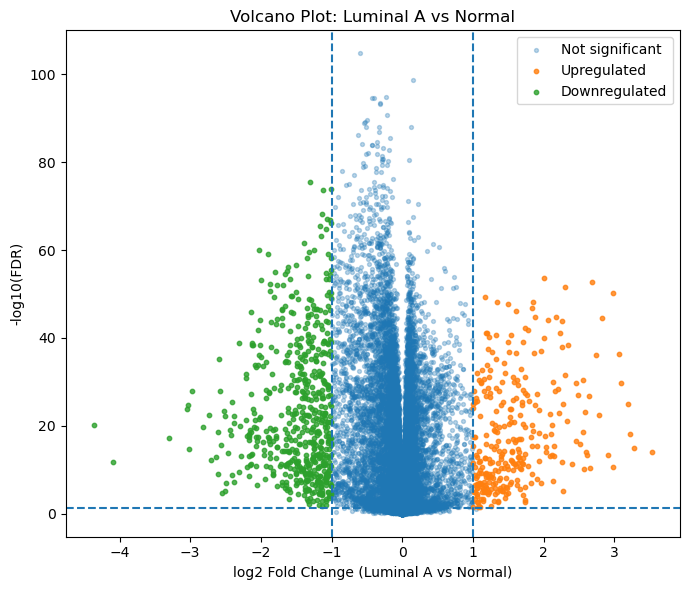

In [136]:
import matplotlib.pyplot as plt
import numpy as np

# thresholds
fc_thr = 1
fdr_thr = 0.05

# prepare values
log2fc = deg_luma_vs_normal["log2FC"]
neglogfdr = -np.log10(deg_luma_vs_normal["FDR"] + 1e-300)

# classify genes
up = (log2fc >= fc_thr) & (deg_luma_vs_normal["FDR"] < fdr_thr)
down = (log2fc <= -fc_thr) & (deg_luma_vs_normal["FDR"] < fdr_thr)
other = ~(up | down)

plt.figure(figsize=(7, 6))

plt.scatter(log2fc[other], neglogfdr[other], s=8, alpha=0.3, label="Not significant")
plt.scatter(log2fc[up], neglogfdr[up], s=10, alpha=0.8, label="Upregulated")
plt.scatter(log2fc[down], neglogfdr[down], s=10, alpha=0.8, label="Downregulated")

# threshold lines
plt.axvline(fc_thr, linestyle="--")
plt.axvline(-fc_thr, linestyle="--")
plt.axhline(-np.log10(fdr_thr), linestyle="--")

plt.xlabel("log2 Fold Change (Luminal A vs Normal)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot: Luminal A vs Normal")
plt.legend()
plt.tight_layout()
plt.show()


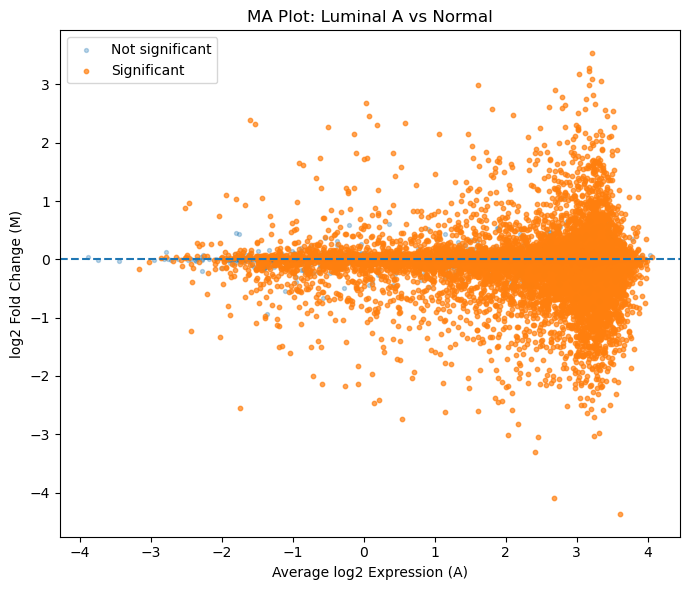

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# compute A (mean expression) and M (log2FC)
A = 0.5 * (np.log2(expr_luma.mean(axis=1) + 1e-6) +
           np.log2(expr_normal.mean(axis=1) + 1e-6))
M = deg_luma_vs_normal["log2FC"]

# significance mask
sig = deg_luma_vs_normal["FDR"] < 0.05

plt.figure(figsize=(7, 6))

plt.scatter(A[~sig], M[~sig], s=8, alpha=0.3, label="Not significant")
plt.scatter(A[sig], M[sig], s=10, alpha=0.7, label="Significant")

plt.axhline(0, linestyle="--")

plt.xlabel("Average log2 Expression (A)")
plt.ylabel("log2 Fold Change (M)")
plt.title("MA Plot: Luminal A vs Normal")
plt.legend()

plt.tight_layout()




In [140]:
# SAVE at 600 DPI (publication ready)
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\MA_LumA_vs_Normal_600dpi.png",
    dpi=600
)

plt.show()

<Figure size 640x480 with 0 Axes>

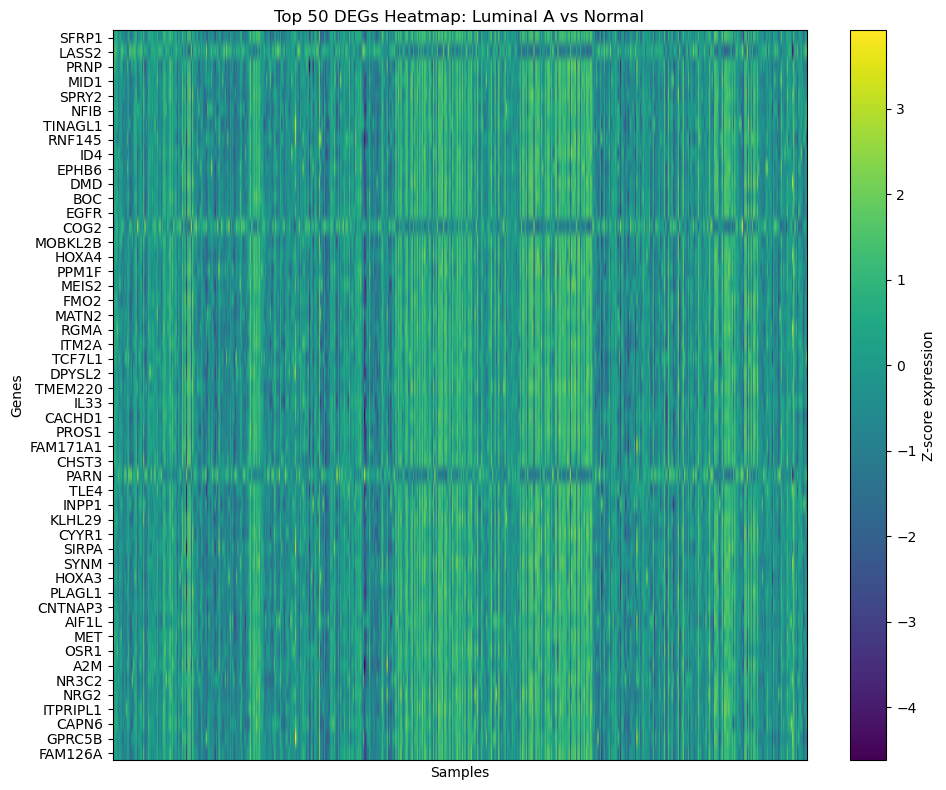

In [142]:
import numpy as np
import matplotlib.pyplot as plt

# select top 50 DEGs by FDR
top_genes = deg_luma_vs_normal.head(50).index

# subset expression
heatmap_data = expr_filt.loc[top_genes, luma_samples.union(normal_samples)]

# z-score per gene (row-wise)
heatmap_z = (heatmap_data - heatmap_data.mean(axis=1).values.reshape(-1, 1)) / \
            heatmap_data.std(axis=1).values.reshape(-1, 1)

plt.figure(figsize=(10, 8))
plt.imshow(heatmap_z, aspect="auto")

plt.colorbar(label="Z-score expression")
plt.yticks(range(len(top_genes)), top_genes)
plt.xticks([])

plt.title("Top 50 DEGs Heatmap: Luminal A vs Normal")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.tight_layout()



In [ ]:
# save at 600 DPI
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Heatmap_Top50_LumA_vs_Normal_600dpi.png",
    dpi=600
)

plt.show()


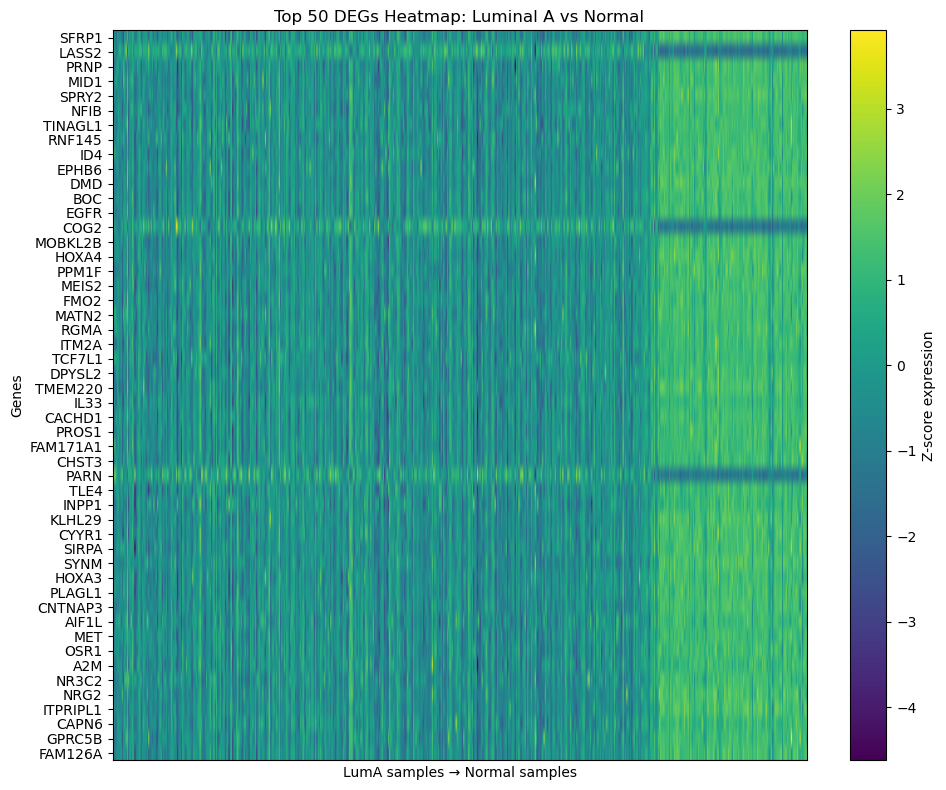

In [144]:
# order samples: LumA first, then Normal
ordered_samples = list(luma_samples) + list(normal_samples)

# subset again with correct order
heatmap_data = expr_filt.loc[top_genes, ordered_samples]

# z-score per gene
heatmap_z = (heatmap_data - heatmap_data.mean(axis=1).values.reshape(-1, 1)) / \
            heatmap_data.std(axis=1).values.reshape(-1, 1)

plt.figure(figsize=(10, 8))
plt.imshow(heatmap_z, aspect="auto")

plt.colorbar(label="Z-score expression")
plt.yticks(range(len(top_genes)), top_genes)
plt.xticks([])

plt.title("Top 50 DEGs Heatmap: Luminal A vs Normal")
plt.xlabel("LumA samples → Normal samples")
plt.ylabel("Genes")

plt.tight_layout()

plt.show()


In [146]:
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Heatmap_Top50_LumA_vs_Normal_ORDERED_600dpi.png",
    dpi=600
)

<Figure size 640x480 with 0 Axes>

In [148]:
# apply DEG thresholds
deg_luma_final = deg_luma_vs_normal[
    (deg_luma_vs_normal["FDR"] < 0.05) &
    (deg_luma_vs_normal["log2FC"].abs() >= 1)
]

# sort by FDR
deg_luma_final = deg_luma_final.sort_values("FDR")

# quick check
deg_luma_final.shape, deg_luma_final.head()


((870, 3),
           log2FC        pvalue           FDR
 sample                                      
 NRG2   -1.311816  9.231185e-79  3.652941e-76
 TRPM6  -1.005007  4.723332e-77  1.563251e-74
 TSLP   -1.115167  6.009728e-77  1.922158e-74
 PTPRZ1 -1.129628  2.496875e-71  5.106811e-69
 CXCL2  -1.059440  5.836953e-70  1.041667e-67)

In [152]:
!pip install openpyxl


In [156]:
# save as CSV
deg_luma_final.to_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\DEGs_LumA_vs_Normal_FDR0.05_log2FC1.csv"
)



# Luminal B vs Normal  

In [159]:
# select sample IDs for LumB and Normal
lumb_samples = pam50[pam50["PAM50"] == "LumB"].index
normal_samples = pam50[pam50["PAM50"] == "Normal"].index

# subset expression matrix
expr_lumb = expr_filt[lumb_samples]
expr_normal = expr_filt[normal_samples]

# check shapes
expr_lumb.shape, expr_normal.shape


((18203, 194), (18203, 119))

In [161]:
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

results = []

for gene in expr_filt.index:
    lumb_vals = expr_lumb.loc[gene].values
    normal_vals = expr_normal.loc[gene].values

    # Welch’s t-test
    stat, pval = ttest_ind(lumb_vals, normal_vals, equal_var=False, nan_policy="omit")

    # log2 fold change
    log2fc = np.mean(lumb_vals) - np.mean(normal_vals)

    results.append((gene, log2fc, pval))

# create dataframe
deg_lumb_vs_normal = pd.DataFrame(
    results, columns=["gene", "log2FC", "pvalue"]
).set_index("gene")

# FDR correction
deg_lumb_vs_normal["FDR"] = (
    deg_lumb_vs_normal["pvalue"]
    .rank(method="first")
    / len(deg_lumb_vs_normal)
    * deg_lumb_vs_normal["pvalue"].sort_values().values
)

# preview
deg_lumb_vs_normal.head()


,log2FC,pvalue,FDR
gene,,,
ARHGEF10L,-0.506300,9.483901e-14,6.469114e-133
HIF3A,-5.406611,1.707049e-74,5.350930e-129
RNF10,0.184569,2.439232e-09,5.274382e-119
RNF11,-0.509206,1.156356e-20,1.699097e-118
RNF13,-0.168786,2.025168e-04,5.167704e-118


In [163]:
from statsmodels.stats.multitest import multipletests

# apply proper BH-FDR correction
deg_lumb_vs_normal["FDR"] = multipletests(
    deg_lumb_vs_normal["pvalue"],
    method="fdr_bh"
)[1]

# sort by FDR
deg_lumb_vs_normal = deg_lumb_vs_normal.sort_values("FDR")

# check again
deg_lumb_vs_normal.head()


,log2FC,pvalue,FDR
gene,,,
SFRP1,-7.371084,1.603449e-132,2.918758e-128
SPRY2,-3.583856,4.024916e-127,3.663277e-123
BOC,-3.227207,1.040190e-118,6.311528e-115
OSR1,-5.349021,5.822413e-118,2.649635e-114
DMD,-4.651292,7.596521e-118,2.765590e-114


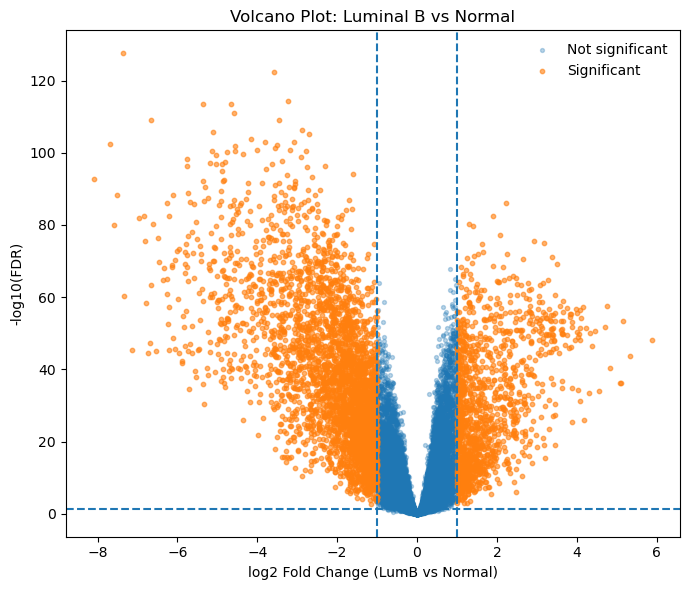

In [165]:
import numpy as np
import matplotlib.pyplot as plt

# prepare values
log2fc = deg_lumb_vs_normal["log2FC"]
fdr = deg_lumb_vs_normal["FDR"]

# define significance
sig = (fdr < 0.05) & (np.abs(log2fc) >= 1)

plt.figure(figsize=(7, 6))

# non-significant
plt.scatter(
    log2fc[~sig],
    -np.log10(fdr[~sig] + 1e-300),
    s=8,
    alpha=0.3,
    label="Not significant"
)

# significant
plt.scatter(
    log2fc[sig],
    -np.log10(fdr[sig] + 1e-300),
    s=10,
    alpha=0.6,
    label="Significant"
)

# threshold lines
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change (LumB vs Normal)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot: Luminal B vs Normal")
plt.legend(frameon=False)

plt.tight_layout()

plt.show()


In [ ]:
# save 600 DPI
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Volcano_LumB_vs_Normal_600dpi.png",
    dpi=600
)

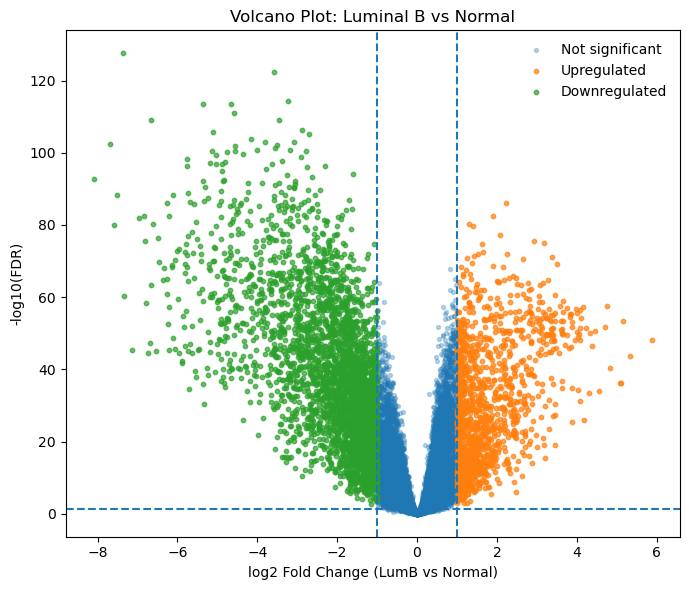

In [167]:
# define groups
up = (deg_lumb_vs_normal["FDR"] < 0.05) & (deg_lumb_vs_normal["log2FC"] >= 1)
down = (deg_lumb_vs_normal["FDR"] < 0.05) & (deg_lumb_vs_normal["log2FC"] <= -1)
ns = ~(up | down)

plt.figure(figsize=(7, 6))

# not significant
plt.scatter(
    deg_lumb_vs_normal.loc[ns, "log2FC"],
    -np.log10(deg_lumb_vs_normal.loc[ns, "FDR"] + 1e-300),
    s=8,
    alpha=0.3,
    label="Not significant"
)

# upregulated
plt.scatter(
    deg_lumb_vs_normal.loc[up, "log2FC"],
    -np.log10(deg_lumb_vs_normal.loc[up, "FDR"] + 1e-300),
    s=10,
    alpha=0.7,
    label="Upregulated"
)

# downregulated
plt.scatter(
    deg_lumb_vs_normal.loc[down, "log2FC"],
    -np.log10(deg_lumb_vs_normal.loc[down, "FDR"] + 1e-300),
    s=10,
    alpha=0.7,
    label="Downregulated"
)

# thresholds
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change (LumB vs Normal)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot: Luminal B vs Normal")
plt.legend(frameon=False)

plt.tight_layout()

plt.show()


In [169]:
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Volcano_LumB_vs_Normal_UpDown_600dpi.png",
    dpi=600
)

<Figure size 640x480 with 0 Axes>

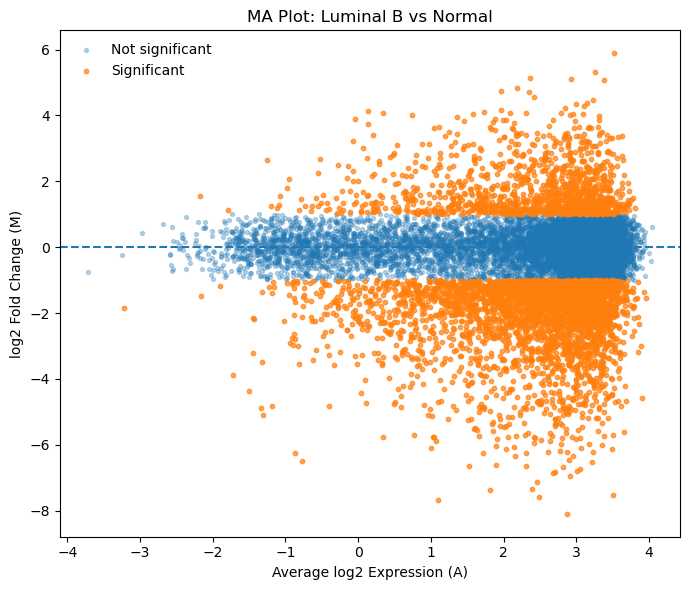

In [171]:
import numpy as np
import matplotlib.pyplot as plt

# compute A (average expression) and M (log2FC)
A = 0.5 * (
    np.log2(expr_lumb.mean(axis=1) + 1e-6) +
    np.log2(expr_normal.mean(axis=1) + 1e-6)
)
M = deg_lumb_vs_normal["log2FC"]

# significance
sig = (deg_lumb_vs_normal["FDR"] < 0.05) & (np.abs(M) >= 1)

plt.figure(figsize=(7, 6))

# not significant
plt.scatter(
    A[~sig],
    M[~sig],
    s=8,
    alpha=0.3,
    label="Not significant"
)

# significant
plt.scatter(
    A[sig],
    M[sig],
    s=10,
    alpha=0.7,
    label="Significant"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Average log2 Expression (A)")
plt.ylabel("log2 Fold Change (M)")
plt.title("MA Plot: Luminal B vs Normal")
plt.legend(frameon=False)

plt.tight_layout()


plt.show()


In [173]:
# save at 600 DPI
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\MA_LumB_vs_Normal_600dpi.png",
    dpi=600
)


<Figure size 640x480 with 0 Axes>

In [175]:
# apply thresholds
deg_lumb_final = deg_lumb_vs_normal[
    (deg_lumb_vs_normal["FDR"] < 0.05) &
    (deg_lumb_vs_normal["log2FC"].abs() >= 1)
]

# sort by FDR
deg_lumb_final = deg_lumb_final.sort_values("FDR")

# quick check
deg_lumb_final.shape, deg_lumb_final.head()


((4682, 3),
          log2FC         pvalue            FDR
 gene                                         
 SFRP1 -7.371084  1.603449e-132  2.918758e-128
 SPRY2 -3.583856  4.024916e-127  3.663277e-123
 BOC   -3.227207  1.040190e-118  6.311528e-115
 OSR1  -5.349021  5.822413e-118  2.649635e-114
 DMD   -4.651292  7.596521e-118  2.765590e-114)

In [177]:
# save as CSV
deg_lumb_final.to_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\DEGs_LumB_vs_Normal_FDR0.05_log2FC1.csv"
)

print("Luminal B DEG table saved (CSV)")


Luminal B DEG table saved (CSV)


# HER2 vs Normal 

In [180]:
# select sample IDs for HER2 and Normal
her2_samples = pam50[pam50["PAM50"] == "Her2"].index
normal_samples = pam50[pam50["PAM50"] == "Normal"].index

# subset expression matrix
expr_her2 = expr_filt[her2_samples]
expr_normal = expr_filt[normal_samples]

# check shapes
expr_her2.shape, expr_normal.shape


((18203, 67), (18203, 119))

In [182]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# containers
results = []

for gene in expr_filt.index:
    her2_vals = expr_her2.loc[gene].values
    normal_vals = expr_normal.loc[gene].values

    # Welch’s t-test
    stat, pval = ttest_ind(
        her2_vals, normal_vals,
        equal_var=False,
        nan_policy="omit"
    )

    # log2 fold change (HER2 - Normal)
    log2fc = np.mean(her2_vals) - np.mean(normal_vals)

    results.append((gene, log2fc, pval))

# create dataframe
deg_her2_vs_normal = pd.DataFrame(
    results, columns=["gene", "log2FC", "pvalue"]
).set_index("gene")

# proper BH-FDR correction
deg_her2_vs_normal["FDR"] = multipletests(
    deg_her2_vs_normal["pvalue"],
    method="fdr_bh"
)[1]

# sort by FDR
deg_her2_vs_normal = deg_her2_vs_normal.sort_values("FDR")

# preview
deg_her2_vs_normal.head()


,log2FC,pvalue,FDR
gene,,,
KLHL29,-3.570156,1.905736e-71,3.469011e-67
RYR3,-3.829400,7.995636e-70,7.277228e-66
SYNM,-4.560958,1.862898e-66,1.130345e-62
LRRC3B,-4.108545,1.343319e-65,6.113111e-62
PDE1C,-4.517016,1.756323e-65,6.394070e-62


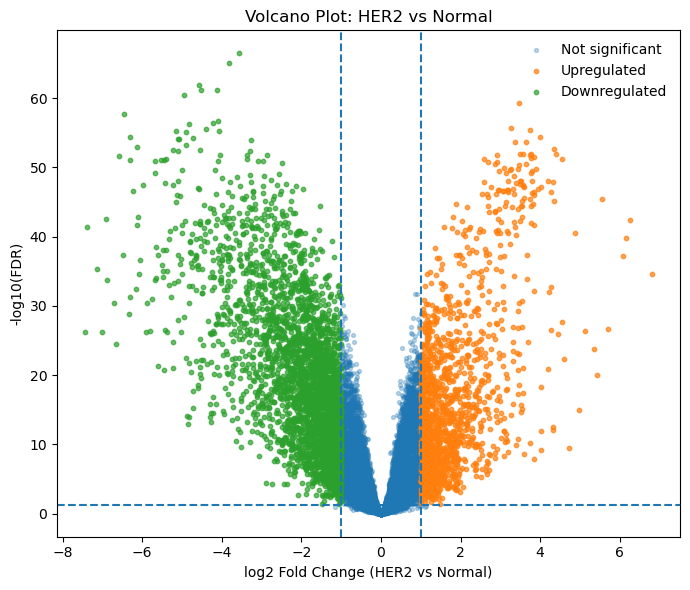

In [184]:
import numpy as np
import matplotlib.pyplot as plt

# define categories
up = (deg_her2_vs_normal["FDR"] < 0.05) & (deg_her2_vs_normal["log2FC"] >= 1)
down = (deg_her2_vs_normal["FDR"] < 0.05) & (deg_her2_vs_normal["log2FC"] <= -1)
ns = ~(up | down)

plt.figure(figsize=(7, 6))

# not significant
plt.scatter(
    deg_her2_vs_normal.loc[ns, "log2FC"],
    -np.log10(deg_her2_vs_normal.loc[ns, "FDR"] + 1e-300),
    s=8,
    alpha=0.3,
    label="Not significant"
)

# upregulated
plt.scatter(
    deg_her2_vs_normal.loc[up, "log2FC"],
    -np.log10(deg_her2_vs_normal.loc[up, "FDR"] + 1e-300),
    s=10,
    alpha=0.7,
    label="Upregulated"
)

# downregulated
plt.scatter(
    deg_her2_vs_normal.loc[down, "log2FC"],
    -np.log10(deg_her2_vs_normal.loc[down, "FDR"] + 1e-300),
    s=10,
    alpha=0.7,
    label="Downregulated"
)

# thresholds
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change (HER2 vs Normal)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot: HER2 vs Normal")
plt.legend(frameon=False)

plt.tight_layout()

plt.show()


In [186]:
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Volcano_HER2_vs_Normal_600dpi.png",
    dpi=600
)

<Figure size 640x480 with 0 Axes>

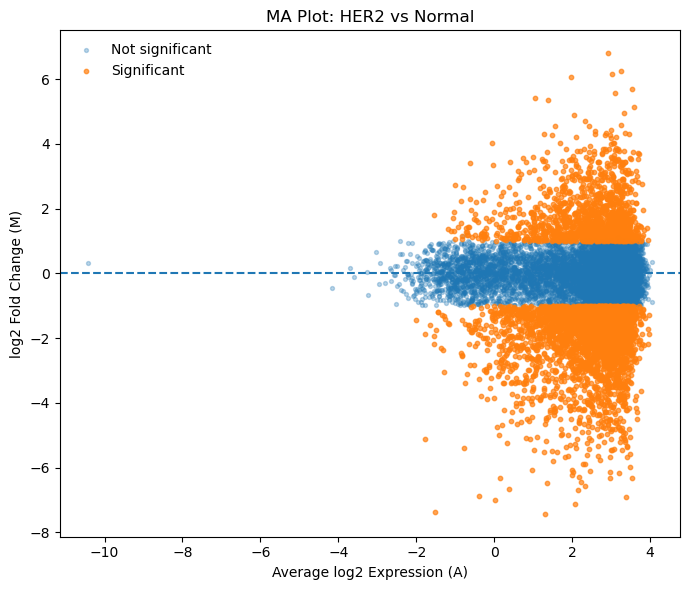

In [188]:
import numpy as np
import matplotlib.pyplot as plt

# compute A (average expression) and M (log2FC)
A = 0.5 * (
    np.log2(expr_her2.mean(axis=1) + 1e-6) +
    np.log2(expr_normal.mean(axis=1) + 1e-6)
)
M = deg_her2_vs_normal["log2FC"]

# significance definition
sig = (deg_her2_vs_normal["FDR"] < 0.05) & (np.abs(M) >= 1)

plt.figure(figsize=(7, 6))

# not significant genes
plt.scatter(
    A[~sig],
    M[~sig],
    s=8,
    alpha=0.3,
    label="Not significant"
)

# significant genes
plt.scatter(
    A[sig],
    M[sig],
    s=10,
    alpha=0.7,
    label="Significant"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Average log2 Expression (A)")
plt.ylabel("log2 Fold Change (M)")
plt.title("MA Plot: HER2 vs Normal")
plt.legend(frameon=False)

plt.tight_layout()


plt.show()


In [190]:
# save at 600 DPI (download-ready)
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\MA_HER2_vs_Normal_600dpi.png",
    dpi=600
)


<Figure size 640x480 with 0 Axes>

In [192]:
# apply thresholds
deg_her2_final = deg_her2_vs_normal[
    (deg_her2_vs_normal["FDR"] < 0.05) &
    (deg_her2_vs_normal["log2FC"].abs() >= 1)
]

# sort by FDR
deg_her2_final = deg_her2_final.sort_values("FDR")

# quick check
deg_her2_final.shape, deg_her2_final.head()


((4684, 3),
           log2FC        pvalue           FDR
 gene                                        
 KLHL29 -3.570156  1.905736e-71  3.469011e-67
 RYR3   -3.829400  7.995636e-70  7.277228e-66
 SYNM   -4.560958  1.862898e-66  1.130345e-62
 LRRC3B -4.108545  1.343319e-65  6.113111e-62
 PDE1C  -4.517016  1.756323e-65  6.394070e-62)

In [194]:
# save as CSV (recommended)
deg_her2_final.to_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\DEGs_HER2_vs_Normal_FDR0.05_log2FC1.csv"
)

print("HER2 DEG table saved (CSV)")


HER2 DEG table saved (CSV)


# TNBC vs Normal

In [197]:
# select sample IDs for TNBC (Basal) and Normal
tnbc_samples = pam50[pam50["PAM50"] == "Basal"].index
normal_samples = pam50[pam50["PAM50"] == "Normal"].index

# subset expression matrix
expr_tnbc = expr_filt[tnbc_samples]
expr_normal = expr_filt[normal_samples]

# check shapes
expr_tnbc.shape, expr_normal.shape


((18203, 142), (18203, 119))

In [199]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

results = []

for gene in expr_filt.index:
    tnbc_vals = expr_tnbc.loc[gene].values
    normal_vals = expr_normal.loc[gene].values

    # Welch’s t-test
    stat, pval = ttest_ind(
        tnbc_vals,
        normal_vals,
        equal_var=False,
        nan_policy="omit"
    )

    # log2 fold change (TNBC - Normal)
    log2fc = np.mean(tnbc_vals) - np.mean(normal_vals)

    results.append((gene, log2fc, pval))

# build dataframe
deg_tnbc_vs_normal = pd.DataFrame(
    results, columns=["gene", "log2FC", "pvalue"]
).set_index("gene")

# BH-FDR correction
deg_tnbc_vs_normal["FDR"] = multipletests(
    deg_tnbc_vs_normal["pvalue"],
    method="fdr_bh"
)[1]

# sort by FDR
deg_tnbc_vs_normal = deg_tnbc_vs_normal.sort_values("FDR")

# preview
deg_tnbc_vs_normal.head()


,log2FC,pvalue,FDR
gene,,,
SCN2B,-5.104518,1.596442e-91,2.906003e-87
ZBTB16,-6.071821,2.193175e-87,1.996119e-83
SDPR,-5.255129,8.754714e-87,3.984051e-83
CENPL,1.949230,6.985968e-87,3.984051e-83
CCNE1,3.955952,1.995257e-86,7.263933e-83


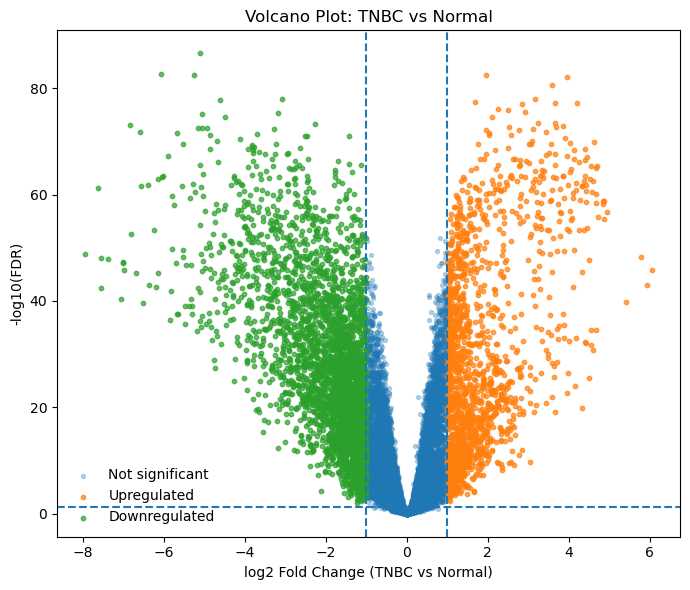

In [201]:
import numpy as np
import matplotlib.pyplot as plt

# define categories
up = (deg_tnbc_vs_normal["FDR"] < 0.05) & (deg_tnbc_vs_normal["log2FC"] >= 1)
down = (deg_tnbc_vs_normal["FDR"] < 0.05) & (deg_tnbc_vs_normal["log2FC"] <= -1)
ns = ~(up | down)

plt.figure(figsize=(7, 6))

# not significant
plt.scatter(
    deg_tnbc_vs_normal.loc[ns, "log2FC"],
    -np.log10(deg_tnbc_vs_normal.loc[ns, "FDR"] + 1e-300),
    s=8,
    alpha=0.3,
    label="Not significant"
)

# upregulated
plt.scatter(
    deg_tnbc_vs_normal.loc[up, "log2FC"],
    -np.log10(deg_tnbc_vs_normal.loc[up, "FDR"] + 1e-300),
    s=10,
    alpha=0.7,
    label="Upregulated"
)

# downregulated
plt.scatter(
    deg_tnbc_vs_normal.loc[down, "log2FC"],
    -np.log10(deg_tnbc_vs_normal.loc[down, "FDR"] + 1e-300),
    s=10,
    alpha=0.7,
    label="Downregulated"
)

# thresholds
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change (TNBC vs Normal)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot: TNBC vs Normal")
plt.legend(frameon=False)

plt.tight_layout()

plt.show()


In [203]:
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Volcano_TNBC_vs_Normal_600dpi.png",
    dpi=600
)


<Figure size 640x480 with 0 Axes>

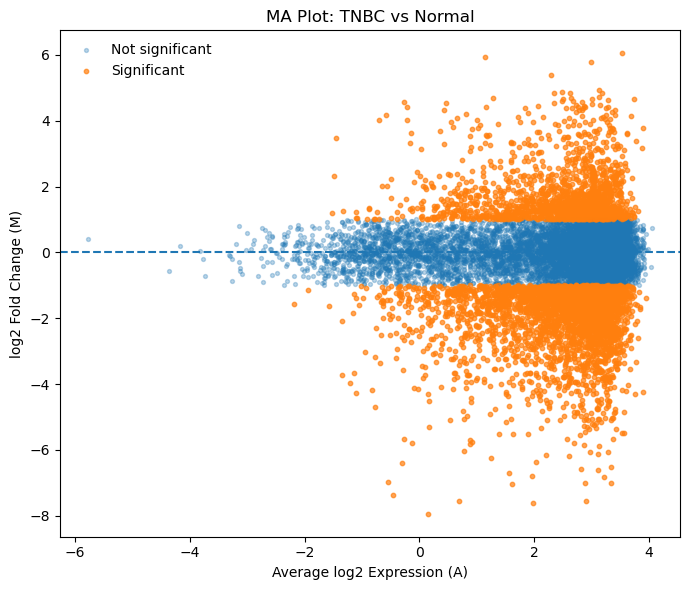

In [205]:
import numpy as np
import matplotlib.pyplot as plt

# compute A (average expression) and M (log2FC)
A = 0.5 * (
    np.log2(expr_tnbc.mean(axis=1) + 1e-6) +
    np.log2(expr_normal.mean(axis=1) + 1e-6)
)
M = deg_tnbc_vs_normal["log2FC"]

# significance definition
sig = (deg_tnbc_vs_normal["FDR"] < 0.05) & (np.abs(M) >= 1)

plt.figure(figsize=(7, 6))

# not significant
plt.scatter(
    A[~sig],
    M[~sig],
    s=8,
    alpha=0.3,
    label="Not significant"
)

# significant
plt.scatter(
    A[sig],
    M[sig],
    s=10,
    alpha=0.7,
    label="Significant"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Average log2 Expression (A)")
plt.ylabel("log2 Fold Change (M)")
plt.title("MA Plot: TNBC vs Normal")
plt.legend(frameon=False)

plt.tight_layout()



plt.show()


In [207]:
# save at 600 DPI
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\MA_TNBC_vs_Normal_600dpi.png",
    dpi=600
)

<Figure size 640x480 with 0 Axes>

In [209]:
# apply thresholds
deg_tnbc_final = deg_tnbc_vs_normal[
    (deg_tnbc_vs_normal["FDR"] < 0.05) &
    (deg_tnbc_vs_normal["log2FC"].abs() >= 1)
]

# sort by FDR
deg_tnbc_final = deg_tnbc_final.sort_values("FDR")

# check
deg_tnbc_final.shape, deg_tnbc_final.head()


((4857, 3),
           log2FC        pvalue           FDR
 gene                                        
 SCN2B  -5.104518  1.596442e-91  2.906003e-87
 ZBTB16 -6.071821  2.193175e-87  1.996119e-83
 SDPR   -5.255129  8.754714e-87  3.984051e-83
 CENPL   1.949230  6.985968e-87  3.984051e-83
 CCNE1   3.955952  1.995257e-86  7.263933e-83)

In [211]:
# save as CSV
deg_tnbc_final.to_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\DEGs_TNBC_vs_Normal_FDR0.05_log2FC1.csv"
)

print("TNBC DEG table saved (CSV)")


TNBC DEG table saved (CSV)
